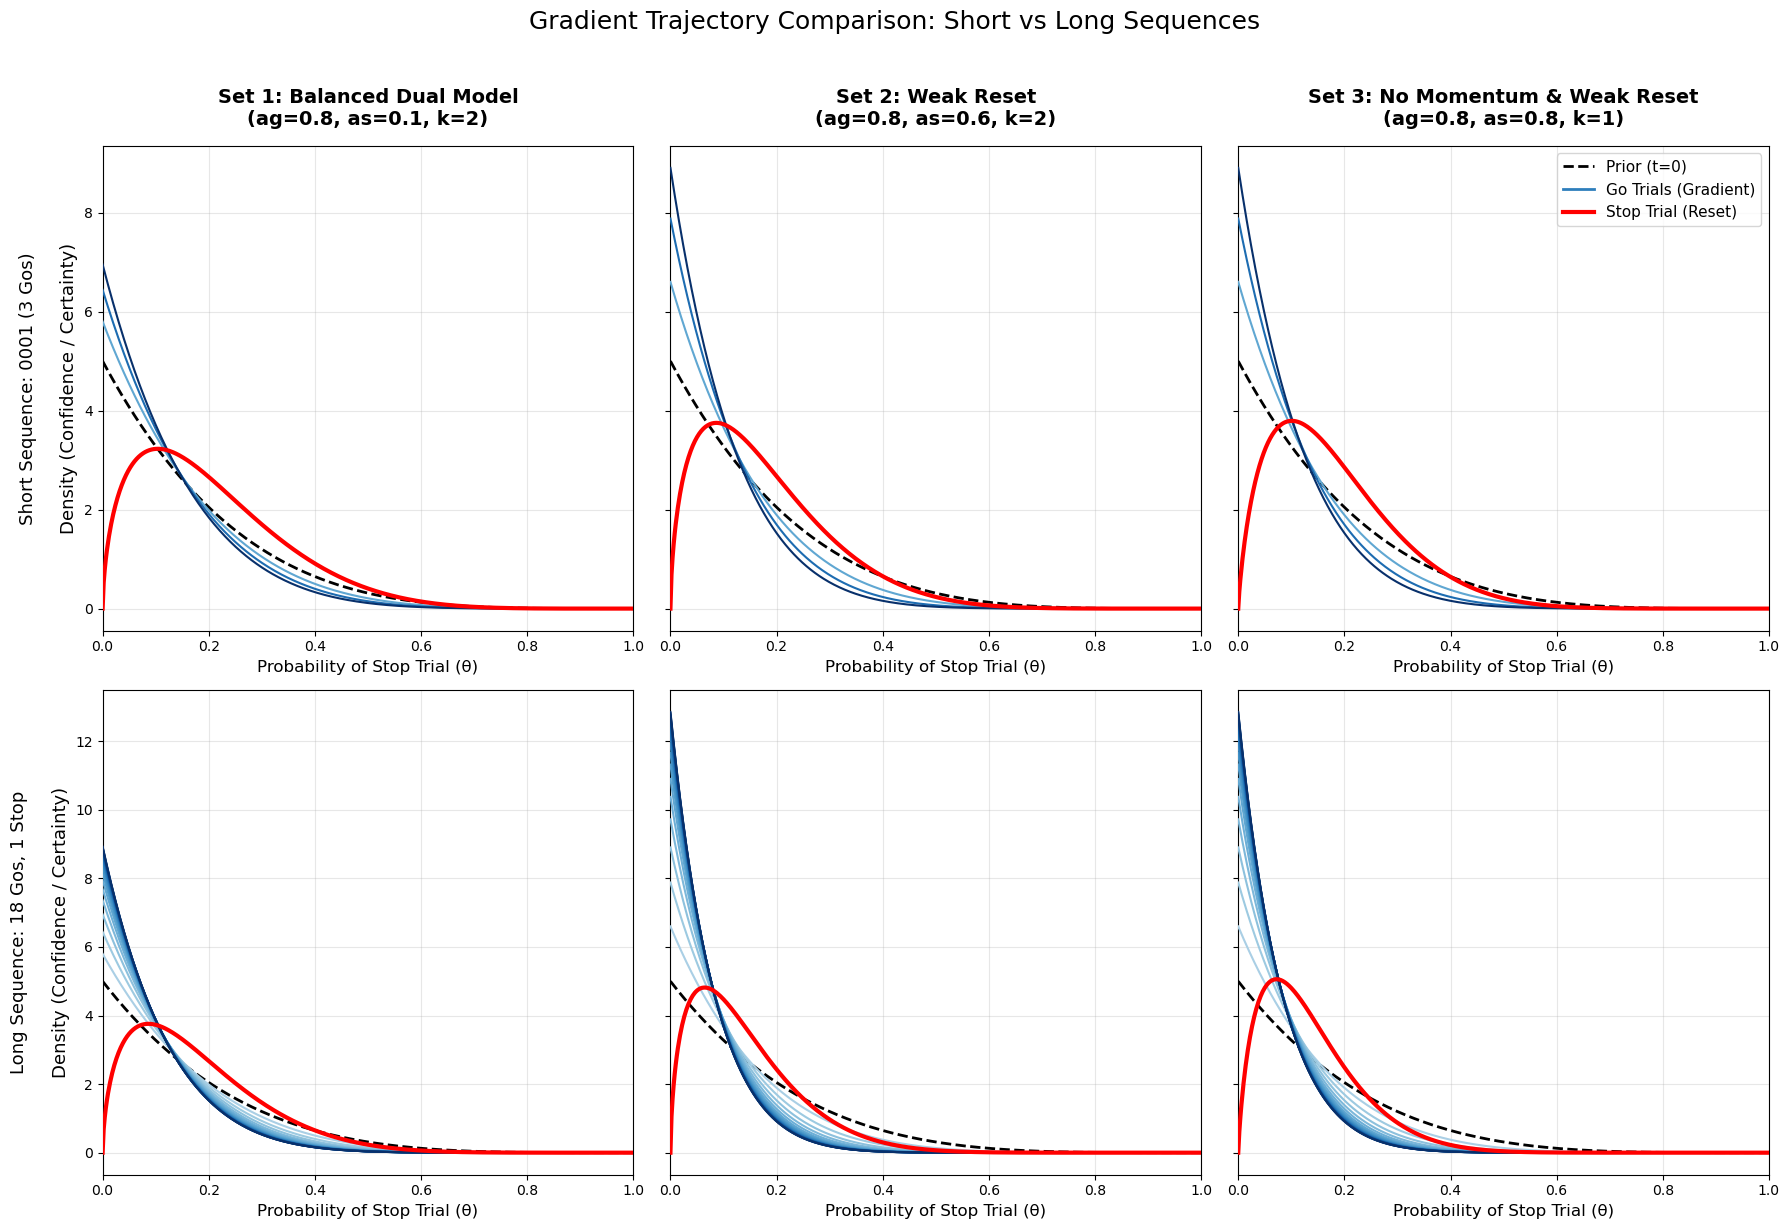

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from matplotlib.lines import Line2D

# 1. 核心模型函数
def simulate_model(trials, a0, b0, alpha_go, alpha_stop, k_go):
    a, b = a0, b0
    history = [(a, b)]
    for t in trials:
        if t == 0: 
            a = (1 - alpha_go) * a0 + alpha_go * (a + k_go)
            b = (1 - alpha_go) * b0 + alpha_go * (b + 0)
        else:      
            a = (1 - alpha_stop) * a0 + alpha_stop * (a + 0)
            b = (1 - alpha_stop) * b0 + alpha_stop * (b + 1)
        history.append((a, b))
    return history

# 2. 三组对比参数
param_sets = [
    {"alpha_go": 0.80, "alpha_stop": 0.60, "k_go": 1.0, "title": "Set 1: Balanced Dual Model\n(ag=0.8, as=0.1, k=2)"},
    {"alpha_go": 0.80, "alpha_stop": 0.60, "k_go": 2.0, "title": "Set 2: Weak Reset\n(ag=0.8, as=0.6, k=2)"},
    {"alpha_go": 0.80, "alpha_stop": 0.80, "k_go": 2.0, "title": "Set 3: No Momentum & Weak Reset\n(ag=0.8, as=0.8, k=1)"}
]

# 3. 设置两个测试序列
seq_short = [0, 0, 0, 1]            # 3 Go, 1 Stop (0001)
seq_long = [0] * 18 + [1]           # 18 Go, 1 Stop
sequences = [seq_short, seq_long]
seq_names = ["Short Sequence: 0001 (3 Gos)", "Long Sequence: 18 Gos, 1 Stop"]

# 4. 可视化绘制 (2行3列)
# 注意 sharey='row'：为了不让第一行(3次Go)被第二行(18次Go)的巨大峰值压扁，我们让它们各自共享自己行的 Y 轴
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey='row')
x = np.linspace(0, 1, 500)
a0, b0 = 5.0, 1.0 
cmap = plt.cm.Blues

# 图例设定
custom_lines = [
    Line2D([0], [0], color='black', linestyle='--', lw=2),
    Line2D([0], [0], color=cmap(0.7), lw=2),
    Line2D([0], [0], color='red', lw=3)
]

for i, seq in enumerate(sequences):
    # 计算当前序列中 Go 的总数，用来计算蓝色的渐变深度
    n_go = sum(1 for t in seq if t == 0) 
    
    for j, params in enumerate(param_sets):
        ax = axes[i, j]
        
        # 运行模型
        history = simulate_model(seq, a0, b0, params["alpha_go"], params["alpha_stop"], params["k_go"])
        
        # 画先验
        ax.plot(x, beta.pdf(x, b0, a0), color='black', linestyle='--', lw=2)
        
        # 画全轨迹
        for t in range(1, len(history)):
            a_t, b_t = history[t]
            
            if seq[t-1] == 1:
                # Stop trial: 红色粗线
                ax.plot(x, beta.pdf(x, b_t, a_t), color='red', lw=3, zorder=10)
            else:
                # Go trials: 蓝色渐变 (映射到 0.3 - 1.0 防止太浅看不清)
                color_intensity = 0.3 + 0.7 * (t / n_go)
                ax.plot(x, beta.pdf(x, b_t, a_t), color=cmap(color_intensity), lw=1.5, zorder=5)
                
        # 排版与格式
        if i == 0:
            ax.set_title(params["title"], fontsize=14, fontweight='bold', pad=15)
        if j == 0:
            ax.set_ylabel(f"{seq_names[i]}\n\nDensity (Confidence / Certainty)", fontsize=13)
        
        ax.set_xlabel('Probability of Stop Trial (θ)', fontsize=12)
        ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.3)
        
        # 仅在右上角放一个图例，保持画面干净
        if i == 0 and j == 2:
            ax.legend(custom_lines, ['Prior (t=0)', 'Go Trials (Gradient)', 'Stop Trial (Reset)'], loc='upper right', fontsize=11)

plt.suptitle('Gradient Trajectory Comparison: Short vs Long Sequences', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()